# 02 Baselines and leakage (E1, E2, E3, E3b)

Train with `python -m src.train_classical`, score with `python -m src.evaluate`.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('../.cache/mpl'))
import pandas as pd
from IPython.display import Image, Markdown, display
pd.set_option('display.max_colwidth', 140)
pd.set_option('display.width', 200)
from src import config
S = pd.read_csv(config.RESULTS / 'experiments.csv')          # mean (and sd) over seeds
BY_SEED = pd.read_csv(config.RESULTS / 'experiments_by_seed.csv')

def table(models, sets, variant='clean', split='template', metric='f1'):
    t = S[S.model.isin(models) & S.set.isin(sets) & (S.variant == variant) & (S.split == split)]
    return t.pivot_table(index='model', columns='set', values=metric).reindex(models).round(3)

## E1: reproduce the published BongoScam result

All 1,508 raw rows, `train_test_split(test_size=0.2, random_state=42)`, default `CountVectorizer` + `MultinomialNB`, as in the BongoScam notebook. They report 98.7% accuracy.

In [2]:
S[(S.variant == 'published') & (S.set == 'test')][['model', 'n', 'accuracy', 'precision', 'recall', 'f1']]

,model,n,accuracy,precision,recall,f1
982,nb_word_counts,302.0,0.9868,0.9814,1.0,0.9906


## E2: random vs template-disjoint split (RQ1)

One split of each kind, then 10 re-drawn splits of each kind so one lucky test set cannot decide the answer.

In [3]:
models = ['majority', 'nb_word_counts', 'nb_char', 'lr_word', 'lr_char']
t = S[S.model.isin(models) & (S.variant == 'clean') & (S.set == 'test')]
t.pivot_table(index='model', columns='split', values='f1').reindex(models).round(3)

split,random,template
model,,
majority,0.694,0.695
nb_word_counts,0.977,0.988
nb_char,0.994,0.921
lr_word,0.994,1.000
lr_char,0.994,0.968


In [4]:
rep = BY_SEED[(BY_SEED.variant == 'repeat') & (BY_SEED.set == 'test')]
rep.groupby(['model', 'split']).f1.agg(['mean', 'std', 'min', 'max']).round(3)

mean    std    min    max
model          split                               
lr_char        random    0.998  0.003  0.994  1.000
               template  0.963  0.021  0.927  0.994
lr_word        random    0.996  0.004  0.988  1.000
               template  0.991  0.006  0.981  1.000
majority       random    0.694  0.000  0.694  0.694
               template  0.695  0.000  0.695  0.695
nb_char        random    0.995  0.004  0.988  1.000
               template  0.926  0.034  0.867  0.975
nb_word_counts random    0.986  0.009  0.966  0.994
               template  0.979  0.009  0.964  0.994

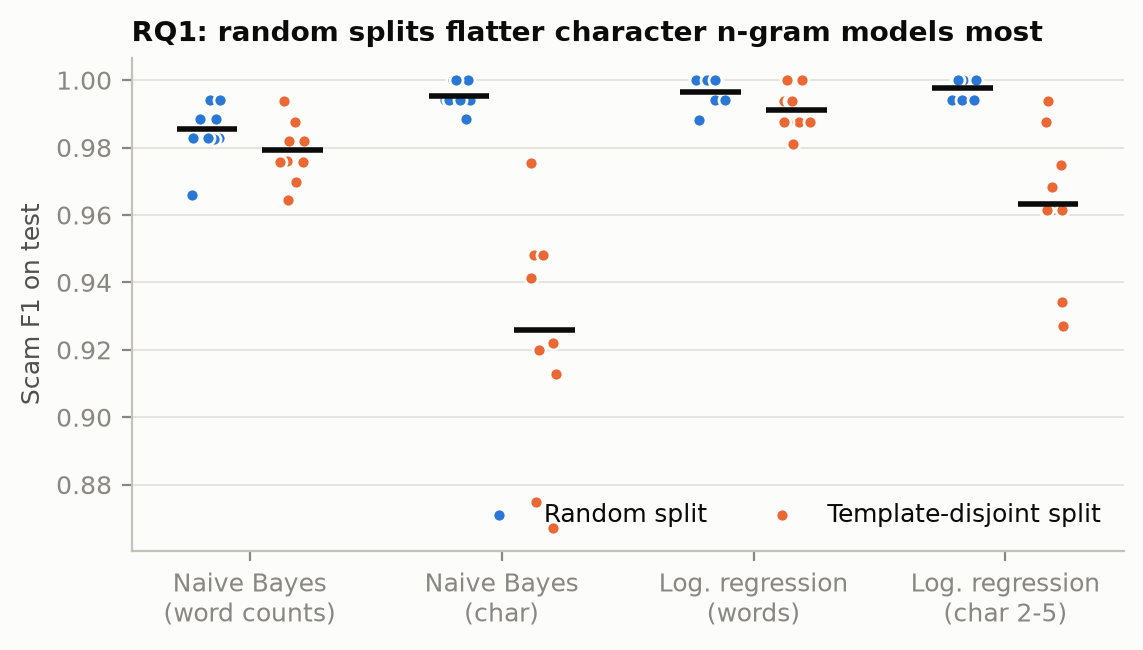

In [5]:
display(Image(str(config.FIGURES / 'rq1_repeated_splits.png')))

**Reading.** Word-level models lose little; character n-gram models lose 3-7 points of F1 when templates cannot leak. Character n-grams memorise the surface form of a script (names, spellings), which a random split rewards.

## E3: word vs character features, masking on vs off

In [6]:
t = S[S.model.isin(models[1:]) & S.variant.isin(['clean', 'nomask']) & (S.split == 'template') & (S.set == 'test')]
t.pivot_table(index='model', columns='variant', values='f1').round(3)

variant,clean,nomask
model,,
lr_char,0.968,0.969
lr_word,1.000,1.000
nb_char,0.921,0.875
nb_word_counts,0.988,0.988


## E3b: the phone-number shortcut

`phone_rule` flags any message with a `<PHONE>` or `<URL>`. The `strip` variant deletes the placeholders everywhere, so models must use the words.

In [7]:
t = S[S.model.isin(['phone_rule'] + models[1:]) & S.variant.isin(['clean', 'strip']) & (S.split == 'template') & S.set.isin(['test', 'test/tpl', 'chichewa/all'])]
t.pivot_table(index=['model', 'variant'], columns='set', values='f1').round(3)

set                     chichewa/all   test  test/tpl
model          variant                               
lr_char        clean           0.651  0.968     1.000
               strip           0.194  0.981     0.980
lr_word        clean           0.494  1.000     1.000
               strip           0.029  0.994     0.990
nb_char        clean           0.305  0.921     0.990
               strip           0.065  0.955     0.980
nb_word_counts clean           0.607  0.988     0.980
               strip           0.407  0.988     0.980
phone_rule     clean           0.681  0.744     0.969

**Reading.** In Swahili the words alone separate the classes (stripping placeholders barely moves test F1). On Chichewa the classical models lose most of their transfer without the placeholder: what transferred was "contains a number", not language.

## What logistic regression learned

In [8]:
feats = json.loads((config.RESULTS / 'lr_top_features.json').read_text())
pd.DataFrame({'scam (word LR)': [f'{w} ({c:.2f})' for w, c in feats['lr_word']['scam'][:15]],
              'not scam (word LR)': [f'{w} ({c:.2f})' for w, c in feats['lr_word']['not_scam'][:15]],
              'scam (char LR)': [repr(w) for w, c in feats['lr_char']['scam'][:15]]})

,scam (word LR),not scam (word LR),scam (char LR)
0,<phone> (12.55),tafadhali (-2.75),' <'
1,jina (7.60),wa (-2.53),'> '
2,namba (7.41),kuhusu (-2.44),'hon'
3,<phone> jina (5.93),sana (-2.32),'ne'
4,kwenye (5.26),leo (-2.17),'one'
5,hii (4.85),kesho (-2.04),'one> '
6,utanitumia (4.63),asante kwa (-2.00),'ne> '
7,piga (4.44),baadaye (-1.75),'<ph'
8,namba hii (4.35),kidogo (-1.68),'<p'
9,<amount> (4.24),saa (-1.65),'ph'
